In [45]:
print("===== EV CHARGING DEMAND FORECASTING =====")
print("Total Records:", len(df))
print("Total Days:", df['date'].nunique())
print("Peak Charging Hour:", peak_hour)
print("Peak Hour Requests:", peak_requests)
print("Weekday Requests:", weekday_demand)
print("Weekend Requests:", weekend_demand)
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

===== EV CHARGING DEMAND FORECASTING =====
Total Records: 8354
Total Days: 88
Peak Charging Hour: 0
Peak Hour Requests: 350
Weekday Requests: 6048
Weekend Requests: 2306
MAE: 2.061743152958581
RMSE: 5.685106678676677
R² Score: -0.037729509050207


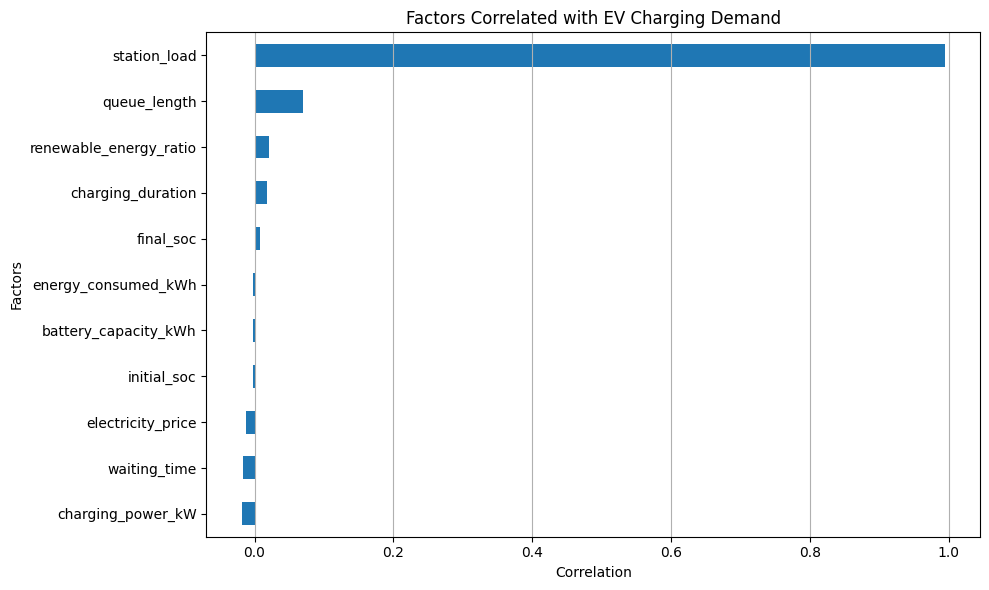

In [44]:
plt.figure(figsize=(10, 6))

correlation.drop('charging_demand').sort_values().plot(kind='barh')

plt.title('Factors Correlated with EV Charging Demand')
plt.xlabel('Correlation')
plt.ylabel('Factors')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [43]:
numeric_cols = [
    'charging_demand',
    'waiting_time',
    'battery_capacity_kWh',
    'initial_soc',
    'final_soc',
    'energy_consumed_kWh',
    'charging_power_kW',
    'charging_duration',
    'queue_length',
    'station_load',
    'electricity_price',
    'renewable_energy_ratio'
]

correlation = df[numeric_cols].corr()['charging_demand'].sort_values(ascending=False)

print("Correlation with Charging Demand:")
print(correlation)

Correlation with Charging Demand:
charging_demand           1.000000
station_load              0.994518
queue_length              0.069824
renewable_energy_ratio    0.020613
charging_duration         0.017773
final_soc                 0.007412
energy_consumed_kWh      -0.001935
battery_capacity_kWh     -0.002324
initial_soc              -0.002912
electricity_price        -0.012021
waiting_time             -0.016734
charging_power_kW        -0.018702
Name: charging_demand, dtype: float64


In [42]:
price_demand = df.groupby('electricity_price')['charging_demand'].mean()

print("Average Charging Demand by Electricity Price:")
print(price_demand)

Average Charging Demand by Electricity Price:
electricity_price
5.00     50.657862
5.01     44.973107
5.02     59.878543
5.03     55.763712
5.04     65.044840
           ...    
14.96    50.302744
14.97    42.839327
14.98    56.172069
14.99    70.738764
15.00    55.837531
Name: charging_demand, Length: 1000, dtype: float64


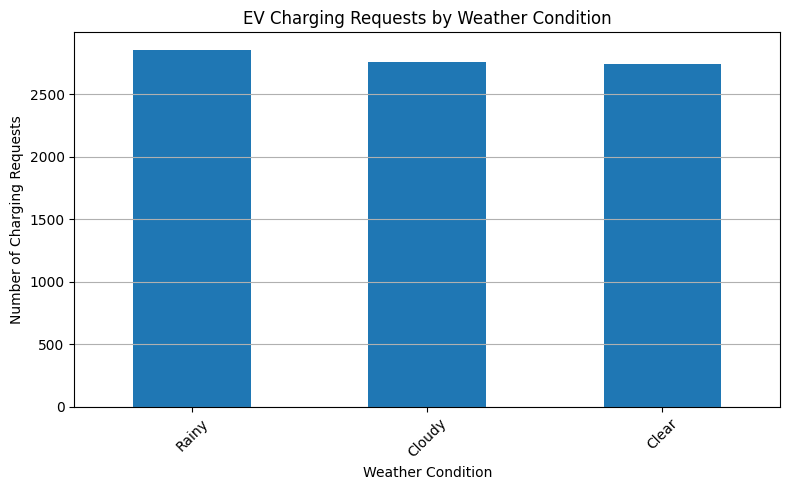

In [41]:
plt.figure(figsize=(8, 5))

weather_demand.plot(kind='bar')

plt.title('EV Charging Requests by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Charging Requests')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [40]:
weather_demand = df.groupby('weather_condition').size().sort_values(ascending=False)

print("Charging Requests by Weather Condition:")
print(weather_demand)

Charging Requests by Weather Condition:
weather_condition
Rainy     2854
Cloudy    2760
Clear     2740
dtype: int64


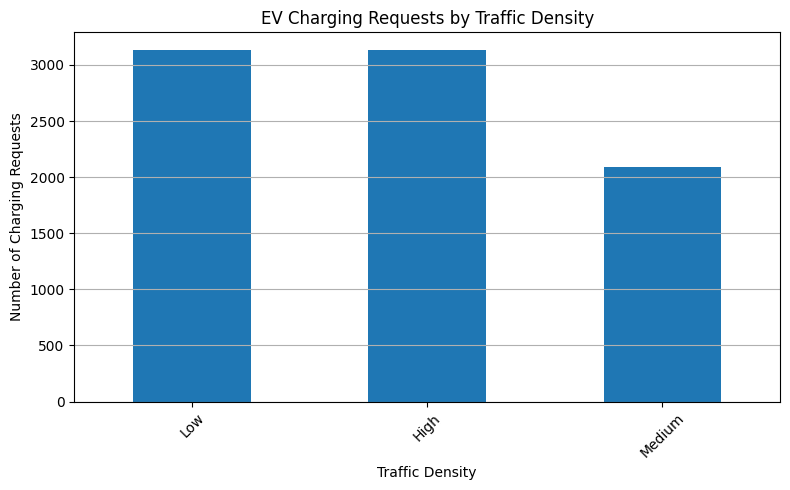

In [39]:
plt.figure(figsize=(8, 5))

traffic_demand.plot(kind='bar')

plt.title('EV Charging Requests by Traffic Density')
plt.xlabel('Traffic Density')
plt.ylabel('Number of Charging Requests')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [38]:
traffic_demand = df.groupby('traffic_density').size().sort_values(ascending=False)

print("Charging Requests by Traffic Density:")
print(traffic_demand)

Charging Requests by Traffic Density:
traffic_density
Low       3134
High      3132
Medium    2088
dtype: int64


In [37]:
print(df.columns.tolist())

['timestamp', 'station_id', 'location_type', 'vehicle_id', 'vehicle_type', 'arrival_time', 'charging_start_time', 'charging_end_time', 'waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW', 'charging_duration', 'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio', 'traffic_density', 'weather_condition', 'day_of_week', 'time_slot', 'charging_demand', 'assigned_charger_id', 'charging_priority', 'optimization_reward', 'arrival_hour', 'date', 'day_name']


In [36]:
traffic_demand = df.groupby('traffic_condition').size().sort_values(ascending=False)

print("Charging Requests by Traffic Condition:")
print(traffic_demand)

KeyError: 'traffic_condition'

In [35]:
[c for c in df.columns if 'user' in c.lower()]

[]

In [34]:
print(df.columns.tolist())

['timestamp', 'station_id', 'location_type', 'vehicle_id', 'vehicle_type', 'arrival_time', 'charging_start_time', 'charging_end_time', 'waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW', 'charging_duration', 'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio', 'traffic_density', 'weather_condition', 'day_of_week', 'time_slot', 'charging_demand', 'assigned_charger_id', 'charging_priority', 'optimization_reward', 'arrival_hour', 'date', 'day_name']


In [33]:
user_type_demand = df.groupby('user_type').size().sort_values(ascending=False)

print("Charging Requests by User Type:")
print(user_type_demand)

KeyError: 'user_type'

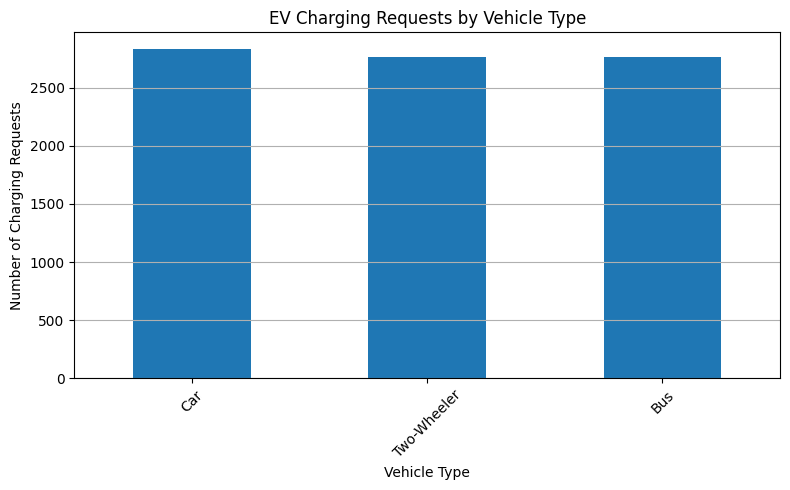

In [32]:
plt.figure(figsize=(8, 5))

vehicle_demand.plot(kind='bar')

plt.title('EV Charging Requests by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Charging Requests')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [31]:
vehicle_demand = df.groupby('vehicle_type').size().sort_values(ascending=False)

print("Charging Requests by Vehicle Type:")
print(vehicle_demand)

Charging Requests by Vehicle Type:
vehicle_type
Car            2833
Two-Wheeler    2761
Bus            2760
dtype: int64


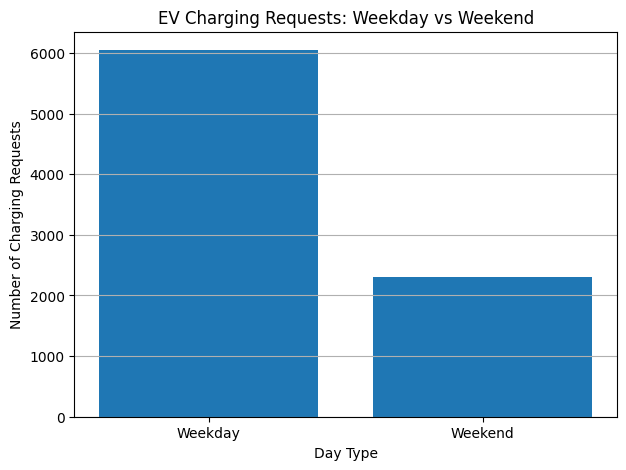

In [30]:
labels = ['Weekday', 'Weekend']
values = [weekday_demand, weekend_demand]

plt.figure(figsize=(7, 5))
plt.bar(labels, values)

plt.title('EV Charging Requests: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Number of Charging Requests')
plt.grid(axis='y')
plt.show()

In [29]:
df['day_name'] = df['arrival_time'].dt.day_name()

weekday_demand = df[df['day_name'].isin([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'
])].shape[0]

weekend_demand = df[df['day_name'].isin([
    'Saturday', 'Sunday'
])].shape[0]

print("Weekday Charging Requests:", weekday_demand)
print("Weekend Charging Requests:", weekend_demand)

Weekday Charging Requests: 6048
Weekend Charging Requests: 2306


In [28]:
top_5_hours = hourly_demand.sort_values(ascending=False).head(5)

print("Top 5 Peak Charging Hours:")
print(top_5_hours)

Top 5 Peak Charging Hours:
arrival_hour
0    350
1    348
2    348
3    348
4    348
dtype: int64


In [27]:
hourly_demand = df.groupby('arrival_hour').size()

peak_hour = hourly_demand.idxmax()
peak_requests = hourly_demand.max()

print("Peak Charging Hour:", peak_hour)
print("Peak Charging Requests:", peak_requests)

Peak Charging Hour: 0
Peak Charging Requests: 350


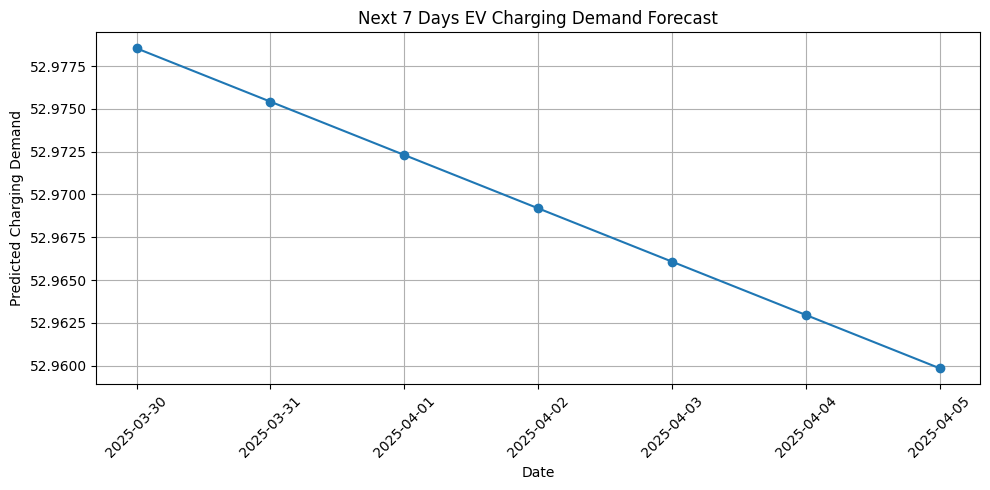

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    future['date'],
    future['predicted_demand'],
    marker='o'
)

plt.title('Next 7 Days EV Charging Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Predicted Charging Demand')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
future_days = 7

future = pd.DataFrame({
    'day_number': range(len(daily_charging_demand),
                        len(daily_charging_demand) + future_days)
})

future['date'] = pd.date_range(
    start=daily_charging_demand['date'].max() + pd.Timedelta(days=1),
    periods=future_days
)

future['predicted_demand'] = model.predict(future[['day_number']])

future

,day_number,date,predicted_demand
0,88,2025-03-30,52.978532
1,89,2025-03-31,52.975418
2,90,2025-04-01,52.972303
3,91,2025-04-02,52.969188
4,92,2025-04-03,52.966074
5,93,2025-04-04,52.962959
6,94,2025-04-05,52.959845


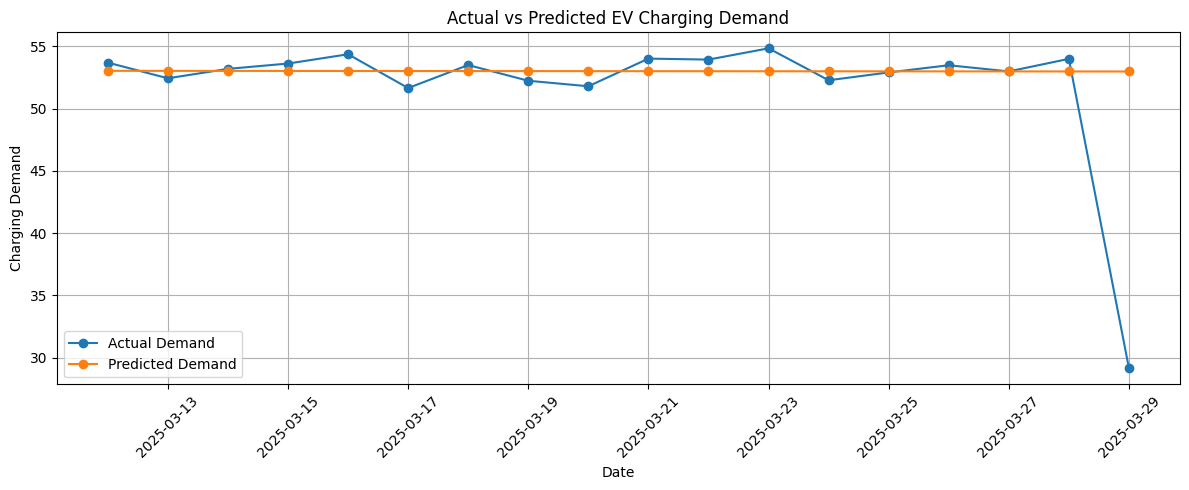

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(
    test['date'],
    test['charging_demand'],
    marker='o',
    label='Actual Demand'
)

plt.plot(
    test['date'],
    test['predicted_demand'],
    marker='o',
    label='Predicted Demand'
)

plt.title('Actual vs Predicted EV Charging Demand')
plt.xlabel('Date')
plt.ylabel('Charging Demand')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(test['charging_demand'], test['predicted_demand'])
rmse = np.sqrt(mean_squared_error(test['charging_demand'], test['predicted_demand']))
r2 = r2_score(test['charging_demand'], test['predicted_demand'])

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 2.061743152958581
RMSE: 5.685106678676677
R² Score: -0.037729509050207


In [22]:
from sklearn.linear_model import LinearRegression

train = train.copy()
test = test.copy()

train['day_number'] = range(len(train))
test['day_number'] = range(len(train), len(train) + len(test))

X_train = train[['day_number']]
y_train = train['charging_demand']

X_test = test[['day_number']]

model = LinearRegression()
model.fit(X_train, y_train)

test['predicted_demand'] = model.predict(X_test)

test.head()

,date,charging_demand,day_number,predicted_demand
70,2025-03-12,53.694052,70,53.034594
71,2025-03-13,52.435061,71,53.031479
72,2025-03-14,53.191387,72,53.028365
73,2025-03-15,53.618612,73,53.025250
74,2025-03-16,54.363558,74,53.022136


In [20]:
train_size = int(len(daily_charging_demand) * 0.8)

train = daily_charging_demand.iloc[:train_size]
test = daily_charging_demand.iloc[train_size:]

print("Training data:", len(train))
print("Testing data:", len(test))

Training data: 70
Testing data: 18


In [19]:
daily_charging_demand = daily_charging_demand.sort_values('date')

daily_charging_demand.head()

,date,charging_demand
0,2025-01-01,51.805875
1,2025-01-02,53.098044
2,2025-01-03,53.036218
3,2025-01-04,53.700332
4,2025-01-05,52.915112


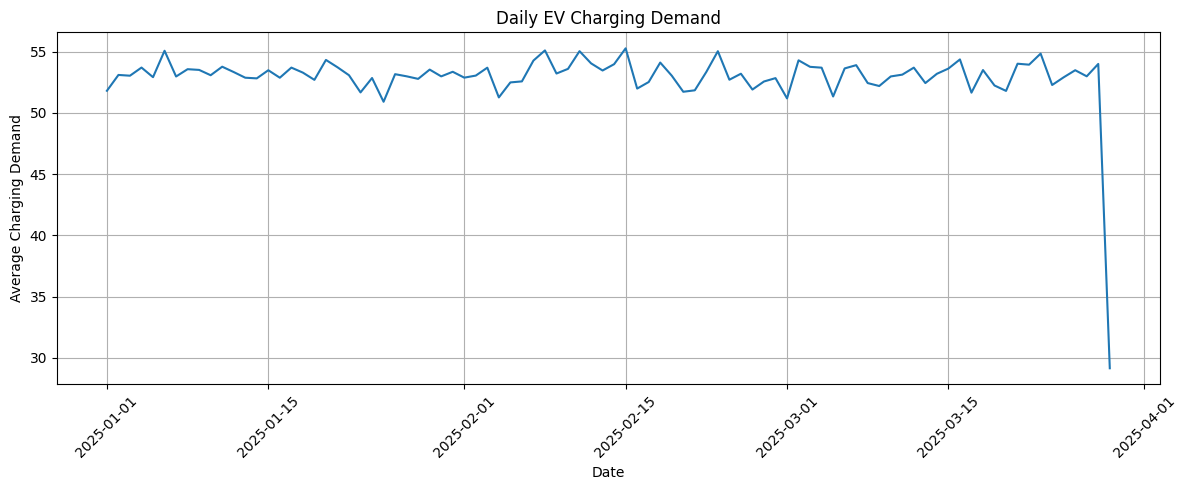

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_charging_demand['date'],
    daily_charging_demand['charging_demand']
)

plt.title('Daily EV Charging Demand')
plt.xlabel('Date')
plt.ylabel('Average Charging Demand')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
daily_charging_demand = df.groupby(df['arrival_time'].dt.date)['charging_demand'].mean()

daily_charging_demand = daily_charging_demand.reset_index()
daily_charging_demand.columns = ['date', 'charging_demand']

daily_charging_demand['date'] = pd.to_datetime(daily_charging_demand['date'])

daily_charging_demand.head()

,date,charging_demand
0,2025-01-01,51.805875
1,2025-01-02,53.098044
2,2025-01-03,53.036218
3,2025-01-04,53.700332
4,2025-01-05,52.915112


In [16]:
df['charging_demand'].describe()

count    8354.000000
mean       53.156126
std        27.563387
min         5.505723
25%        27.911603
50%        49.513337
75%        77.845036
max       104.985659
Name: charging_demand, dtype: float64

In [15]:
df.isnull().sum()

timestamp                 0
station_id                0
location_type             0
vehicle_id                0
vehicle_type              0
arrival_time              0
charging_start_time       0
charging_end_time         0
waiting_time              0
battery_capacity_kWh      0
initial_soc               0
final_soc                 0
energy_consumed_kWh       0
charging_power_kW         0
charging_duration         0
queue_length              0
station_load              0
electricity_price         0
renewable_energy_ratio    0
traffic_density           0
weather_condition         0
day_of_week               0
time_slot                 0
charging_demand           0
assigned_charger_id       0
charging_priority         0
optimization_reward       0
arrival_hour              0
date                      0
dtype: int64

In [14]:
print("Start date:", daily_demand['date'].min())
print("End date:", daily_demand['date'].max())
print("Total days:", daily_demand['date'].nunique())

Start date: 2025-01-01 00:00:00
End date: 2025-03-29 00:00:00
Total days: 88


In [13]:
daily_demand = daily_demand.reset_index()

daily_demand.columns = ['date', 'charging_demand']

daily_demand['date'] = pd.to_datetime(daily_demand['date'])

daily_demand.head()

,date,charging_demand
0,2025-01-01,96
1,2025-01-02,96
2,2025-01-03,96
3,2025-01-04,96
4,2025-01-05,96


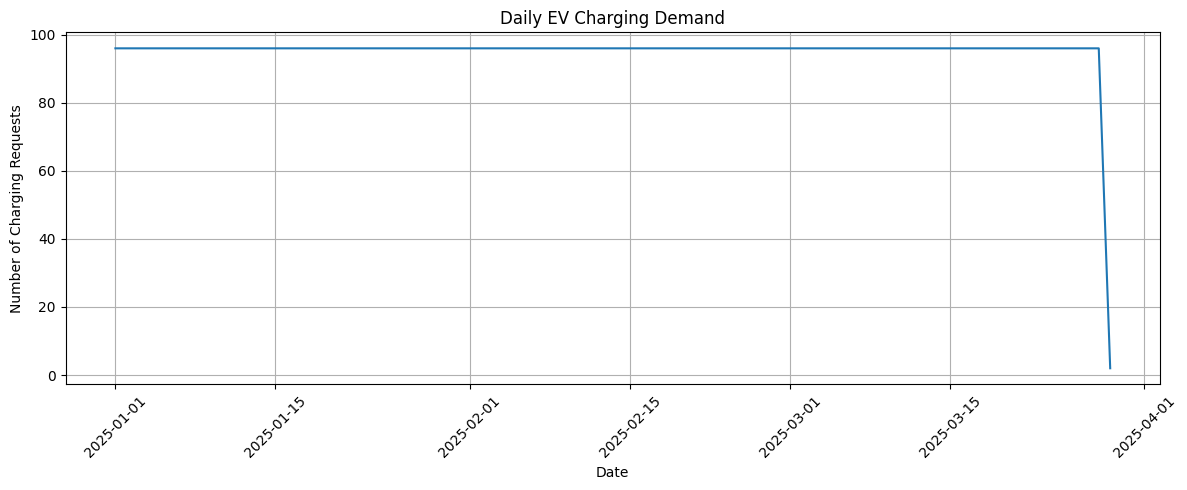

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(daily_demand.index, daily_demand.values)

plt.title('Daily EV Charging Demand')
plt.xlabel('Date')
plt.ylabel('Number of Charging Requests')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
df['date'] = df['arrival_time'].dt.date

daily_demand = df.groupby('date').size()

daily_demand.head()

date
2025-01-01    96
2025-01-02    96
2025-01-03    96
2025-01-04    96
2025-01-05    96
dtype: int64

In [10]:
peak_hours = hourly_demand.sort_values(ascending=False)

peak_hours.head(5)

arrival_hour
0    350
1    348
2    348
3    348
4    348
dtype: int64

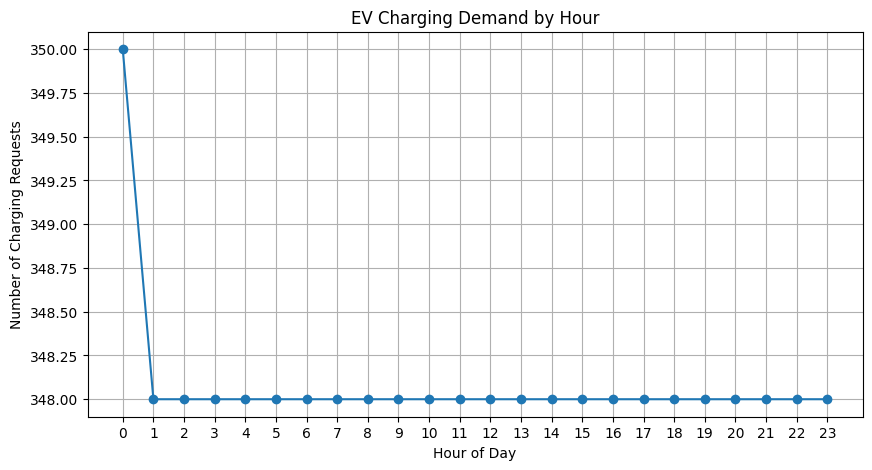

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(hourly_demand.index, hourly_demand.values, marker='o')

plt.title('EV Charging Demand by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Charging Requests')
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [8]:
import matplotlib.pyplot as plt

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(hourly_demand.index, hourly_demand.values, marker='o')

plt.title('EV Charging Demand by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Charging Requests')
plt.xticks(range(24))
plt.grid(True)

plt.show()

NameError: name 'plt' is not defined

In [6]:
df['arrival_hour'] = df['arrival_time'].dt.hour

hourly_demand = df.groupby('arrival_hour').size()

hourly_demand

arrival_hour
0     350
1     348
2     348
3     348
4     348
5     348
6     348
7     348
8     348
9     348
10    348
11    348
12    348
13    348
14    348
15    348
16    348
17    348
18    348
19    348
20    348
21    348
22    348
23    348
dtype: int64

In [5]:
df['arrival_time'] = pd.to_datetime(df['arrival_time'])
df['charging_start_time'] = pd.to_datetime(df['charging_start_time'])
df['charging_end_time'] = pd.to_datetime(df['charging_end_time'])

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   str    
 1   station_id              8354 non-null   str    
 2   location_type           8354 non-null   str    
 3   vehicle_id              8354 non-null   str    
 4   vehicle_type            8354 non-null   str    
 5   arrival_time            8354 non-null   str    
 6   charging_start_time     8354 non-null   str    
 7   charging_end_time       8354 non-null   str    
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   float64
 15

In [3]:
df.head()

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,2025-01-01 00:00:00,ST004,Urban,EV10000,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,2025-01-01 00:15:00,ST005,Urban,EV10001,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,2025-01-01 00:30:00,ST019,Highway,EV10002,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,2025-01-01 00:45:00,ST008,Urban,EV10003,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,2025-01-01 01:00:00,ST008,Highway,EV10004,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [2]:
df = pd.read_csv("ev_charging_dataset.csv")

In [1]:
import pandas as pd